## Exploring your own dataset

Having identified a dataset of interest to you, use this notebook to carry out whatever analyses you care to.  Remove the content from this Markdown cell, and populate the notebook with commentary, code, analyses, results, and figures as you see fit.

Enjoy!

# Austin 311 Data

We will first import the boundaries of Austin neighborhoods to serve as a basemap. We will then import the 311 data from 2025, and visualize it on top of the basemap.

In [15]:
# Import libraries for data analysis and mapping
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [16]:
atx = pd.read_csv(r"Boundaries__City_of_Austin_Neighborhoods.csv")
atx.head()

,Shape__Area,PLANNING_AREA_NAME,COMBINED_NPA,GIS_ID,the_geom,DATE_ZONING_APPROVED,NEIGHBORHOOD_PLANNING_STATUS,NEIGHBORHOOD_SUB_DISTRICT,MODIFIED_DATE,SUBDISTRICT_NUMBER,COMBINED,OBJECTID,INFILL_OPTION_CODES,INTERNET_ADDRESS,CREATED_BY,NEIGHBORHOOD_NUMBER,ORDINANCE_NUMBER,MODIFIED_BY,CREATED_DATE,Shape__Length
0,3.325900e+07,BOULDIN CREEK,BOULDIN CREEK,88,"MULTIPOLYGON (((-97.7596299 30.2421165, -97.75...",05/23/2002 12:00:00 AM +0000,PLAN APPROVED,NONE,09/22/2021 09:51:22 AM +0000,NaN,NO,1,NaN,http://www.austintexas.gov/page/adopted-neighb...,NaN,40,20020523-032,HPD_ADMIN,NaN,25667.340376
1,3.651524e+07,SOUTH MANCHACA,South Austin Combined NPA,667,"MULTIPOLYGON (((-97.788467 30.2297249, -97.789...",11/06/2014 12:00:00 AM +0000,PLAN APPROVED,NaN,09/22/2021 09:51:22 AM +0000,NaN,YES,2,SA/PP/GP/FP,http://www.austintexas.gov/page/adopted-neighb...,NaN,5,20141106-085,HPD_ADMIN,NaN,40031.332399
2,4.160776e+06,HIGHLAND,Brentwood/Highland Combined NPA,5,"MULTIPOLYGON (((-97.7235127 30.3304395, -97.72...",05/13/2004 12:00:00 AM +0000,PLAN APPROVED,SOUTH HIGHLAND,09/22/2021 09:51:22 AM +0000,NaN,YES,3,SLA/CL/SA/PP/GP/FP,http://www.austintexas.gov/page/adopted-neighb...,NaN,27,20040513-030,HPD_ADMIN,NaN,8681.365023
3,2.339275e+07,WESTGATE,South Austin Combined NPA,72,"MULTIPOLYGON (((-97.788467 30.2297249, -97.788...",11/06/2014 12:00:00 AM +0000,PLAN APPROVED,NONE,09/22/2021 09:51:22 AM +0000,NaN,YES,4,PP/GP/FP,http://www.austintexas.gov/page/adopted-neighb...,NaN,80,20141106-085,HPD_ADMIN,NaN,20150.537980
4,3.877298e+05,WEST CONGRESS,South Congress Combined NPA,81,"MULTIPOLYGON (((-97.7708893 30.2242726, -97.76...",08/18/2005 12:00:00 AM +0000,PLAN APPROVED,NORMANDY-CLARKE,09/22/2021 09:51:22 AM +0000,NaN,YES,5,SLA/SA/PP/GP/FP,http://www.austintexas.gov/page/adopted-neighb...,NaN,51,20050818-Z001,HPD_ADMIN,NaN,2512.696781


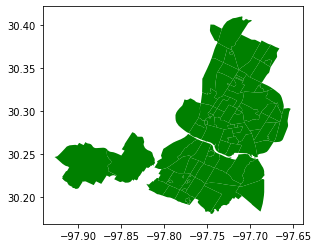

In [17]:
atx['geometry'] = atx['the_geom'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(atx, geometry = 'geometry', crs="EPSG:4326")
gdf.plot(color = 'green')

In [19]:
df = pd.read_csv(r"Austin_311_Public_Data_20250909.csv")
df.head()

,Service Request (SR) Number,SR Description,Owning Department,Method Received,SR Status,Status Change Date,Created Date,Last Update Date,Close Date,SR Location,...,Zip Code,County,State Plane X Coordinate,State Plane Y Coordinate,Latitude Coordinate,Longitude Coordinate,(Latitude.Longitude),Council District,Map Page,Map Tile
0,25-00000782,APD - Non Emergency Noise/Alarm,Austin Police Department,Spot311 Interface,Closed,01/01/2025 07:12:49 PM,01/01/2025 07:07:50 PM,01/01/2025 07:12:49 PM,01/01/2025 07:12:49 PM,"9410 TEASDALE TER, AUSTIN, TX 78753",...,78753.0,TRAVIS,3.133046e+06,1.010290e+07,30.355212,-97.681057,POINT (-97.68105709 30.35521194),4.0,526L,MM29
1,25-00000783,TPW - Traffic Sign Maintenance,Transportation and Public Works,Citizen Web Intake,Closed,01/02/2025 06:58:00 AM,01/01/2025 07:09:52 PM,01/02/2025 07:03:31 AM,01/02/2025 06:58:00 AM,"9718 CURLEW DR, AUSTIN, TX 78748",...,78748.0,TRAVIS,3.086320e+06,1.003766e+07,30.178854,-97.833812,POINT (-97.83381199 30.17885429),5.0,672M,MD14
2,25-00000784,ZZ - AFD - Fireworks Complaint,Austin Fire Department,Phone,Closed,01/04/2025 01:24:06 PM,01/01/2025 07:10:41 PM,01/04/2025 01:24:06 PM,01/04/2025 01:24:06 PM,"5601 EMMA THOMPSON WAY, AUSTIN, TX 78747",...,78747.0,TRAVIS,3.107099e+06,1.002474e+07,30.142050,-97.769012,POINT (-97.76901184 30.1420499),2.0,704L,MH11
3,25-00000786,ARR - Dead Animal Collection,Austin Resource Recovery,Phone,Closed,01/02/2025 08:20:28 AM,01/01/2025 07:12:09 PM,01/02/2025 08:20:28 AM,01/02/2025 08:20:28 AM,"907 E ST JOHNS AVE, AUSTIN, TX 78752",...,78752.0,TRAVIS,3.126837e+06,1.009402e+07,30.331223,-97.701403,POINT (-97.701403 30.33122348),4.0,556A,ML27
4,25-00000788,311 CC - Other,311-Command Center,Spot311 Interface,Closed,01/02/2025 08:26:51 AM,01/01/2025 07:13:54 PM,01/02/2025 08:26:51 AM,01/02/2025 08:26:51 AM,"7033 UNION PARK LN, AUSTIN, TX 78744",...,78744.0,TRAVIS,3.121734e+06,1.003054e+07,30.157050,-97.722295,POINT (-97.72229528 30.15704974),2.0,675Y,MK13


In [20]:
pd.set_option('display.max_rows', None)
df2 = pd.DataFrame(df['SR Description'].value_counts())
df2

,SR Description
ARR - Garbage,17481
APD - Non Emergency Noise/Alarm,17367
DSD - Request Code Officer,16595
TPW - Parking Violation Enforcement,12782
ARR - Compost,9880
ARR - Bulk,8953
ARR - Recycling,8539
TPW - Traffic Signal - Maintenance,8155
APD - Vehicle Abatement Report,6243
Animal Protection - Loose Dog,5676


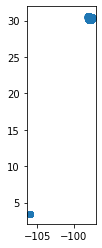

In [21]:
gdf2 = gpd.GeoDataFrame(df, geometry = gpd.points_from_xy(df['Longitude Coordinate'], df['Latitude Coordinate']), crs = "EPSG:4326")
gdf2.plot()

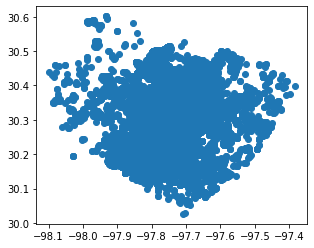

In [22]:
gdf2 = gdf2[gdf2['Longitude Coordinate'] >= -100]
gdf2.plot()

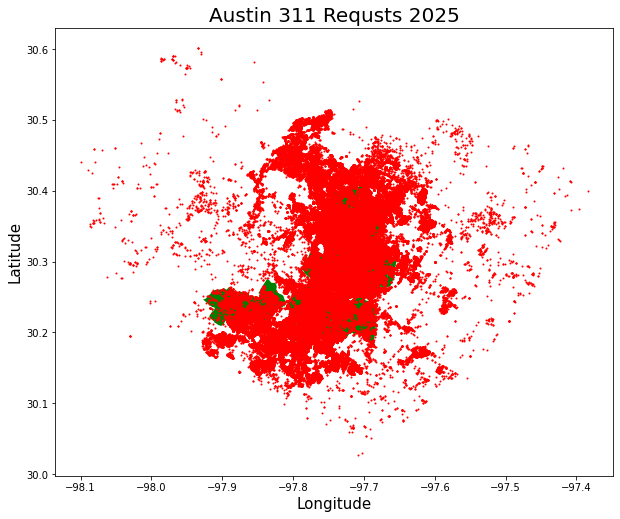

In [23]:
#gdf2_clip = gdf2.clip(gdf)
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Austin 311 Requsts 2025", fontsize= 20)
ax.set_xlabel("Longitude", fontsize = 15)
ax.set_ylabel("Latitude", fontsize = 15)
gdf.plot(ax=ax, color = 'green')
gdf2.plot(ax=ax, color = 'red', legend = True, markersize = 1)
plt.show()

# Apply Machine Learning Models

It can be hard to discern a pattern from the map we created alone, therefore we will try to gain more insights from the data using predictive modeling. We will train the model to predict the owning department from the point location.

In [24]:
import numpy as np

cols_to_include = ['SR Description', 'Latitude Coordinate', 'Longitude Coordinate',]

renaming = {'SR Description': 'Request', 'Latitude Coordinate': 'Lat', 'Longitude Coordinate': 'Long'}

df = df[cols_to_include].rename(renaming, axis =1)
key_vars = ['Lat', 'Long']
df.head()

,Request,Lat,Long
0,APD - Non Emergency Noise/Alarm,30.355212,-97.681057
1,TPW - Traffic Sign Maintenance,30.178854,-97.833812
2,ZZ - AFD - Fireworks Complaint,30.142050,-97.769012
3,ARR - Dead Animal Collection,30.331223,-97.701403
4,311 CC - Other,30.157050,-97.722295


In [25]:
x = df[key_vars]
y = df['Request']
print(x.shape, y.shape)

(214313, 2) (214313,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(x)
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns = x.columns, index = x.index)

print(np.mean(x_scaled, axis=0))
print(np.std(x_scaled, axis=0))

x_scaled.head()

Lat    -7.782879e-15
Long    6.501942e-14
dtype: float64
Lat     1.0
Long    1.0
dtype: float64


,Lat,Long
0,0.099755,0.203457
1,-0.048435,-0.210335
2,-0.079361,-0.034800
3,0.079598,0.148343
4,-0.066757,0.091748


In [27]:
from sklearn import svm, tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, random_state = 0)

In [29]:
clf1 = svm.SVC()
clf1.fit(x_train, y_train)
predictions1 = clf1.predict(x_test)
score1 = accuracy_score(y_test, predictions1)
print(score1)

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [30]:
clf2 = tree.DecisionTreeClassifier(random_state=0)
clf2.fit(x_train, y_train)
predictions2 = clf2.predict(x_test)
score2 = accuracy_score(y_test, predictions2)
print(score2)

ValueError: Input contains NaN, infinity or a value too large for dtype('float32').

In [31]:
for i in range(20):
    x_train, x_test, y_train, y_test = train_test_split(x_scaled, y)
    clf1.fit(x_train, y_train)
    predictions1 = clf1.predict(x_test)
    score1 = accuracy_score(y_test, predictions1)
    clf2.fit(x_train, y_train)
    predictions2 = clf2.predict(x_test)
    score2 = accuracy_score(y_test, predictions2)
    print(score1, score2, score1-score2)

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [32]:
import matplotlib
all_scores1 = []
all_scores2 = []
for i in range(1000):
    x_train, x_test, y_train, y_test = train_test_split(x_scaled, y)
    clf1.fit(x_train, y_train)
    predictions1 = clf1.predict(x_test)
    score1 = accuracy_score(y_test, predictions1)
    clf2.fit(x_train, y_train)
    predictions2 = clf2.predict(x_test)
    score2 = accuracy_score(y_test, predictions2)
    all_scores1.append(score1)
    all_scores2.append(score2)
    
plt.hist(all_scores1, bins = 20, alpha = 0.5, label = 'clf1')
plt.hist(all_scores2, bins = 20, alpha = 0.5, label = 'clf2')
#matplotlib.artist.Artist.set_alpha(alpha = 0.5)
plt.legend()
plt.show()

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').